# PGA Tour – Traditionell statistikanalys
Spelare × säsong, 2010–2018. Källa: PGA Tour via Kaggle (jmpark746).

### Bibliotek

`pandas` för datatabeller, `numpy` för numeriska beräkningar och `matplotlib` för diagram.

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Läs in data

Datasetet läses in från CSV. Spelarnamn görs om till kategorisk typ och penningkolumnen rensas från dollartecken och kommatecken och konverteras till float.

In [130]:
csv_path = "data/pga-traditional/pgaTourData.csv"

df = pd.read_csv(csv_path)

df["Player Name"] = df["Player Name"].astype("category")
df["Money"] = df["Money"].str.replace(r"[$,]", "", regex=True).astype(float)

### Förhandsgranskning

De fem första raderna ger en snabb känsla för dataformatet och kolumnnamnen.

In [131]:
df.head()

,Player Name,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Points,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG,Money
0,Henrik Stenson,60.0,75.19,2018,291.5,73.51,29.93,60.67,69.617,868,NaN,5.0,-0.207,1.153,0.427,0.960,-0.027,2680487.0
1,Ryan Armour,109.0,73.58,2018,283.5,68.22,29.31,60.13,70.758,"1,006",1.0,3.0,-0.058,0.337,-0.012,0.213,0.194,2485203.0
2,Chez Reavie,93.0,72.24,2018,286.5,68.67,29.12,62.27,70.432,"1,020",NaN,3.0,0.192,0.674,0.183,0.437,-0.137,2700018.0
3,Ryan Moore,78.0,71.94,2018,289.2,68.80,29.17,64.16,70.015,795,NaN,5.0,-0.271,0.941,0.406,0.532,0.273,1986608.0
4,Brian Stuard,103.0,71.44,2018,278.9,67.12,29.11,59.23,71.038,421,NaN,3.0,0.164,0.062,-0.227,0.099,0.026,1089763.0


### Statistisk sammanfattning

`describe()` ger antal observationer, medelvärde, standardavvikelse och percentiler för varje numerisk kolumn — en snabb kontroll av datakvalitet och spridning.

In [132]:
df.describe()

,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG,Money
count,1678.000000,1678.000000,2312.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,293.000000,1458.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,2.300000e+03
mean,78.711561,61.440560,2013.996107,290.807688,65.661675,29.163331,58.115638,70.921961,1.218430,2.781893,0.025641,0.148105,0.037759,0.065015,0.019974,1.124903e+06
std,14.274137,5.058845,2.581176,8.916631,2.745411,0.518468,3.384769,0.698305,0.573443,1.895094,0.343787,0.694923,0.379892,0.380952,0.223361,1.354085e+06
min,45.000000,43.020000,2010.000000,266.400000,53.540000,27.510000,44.010000,68.698000,1.000000,1.000000,-1.475000,-3.209000,-1.717000,-1.680000,-0.930000,5.520000e+03
25%,69.000000,57.942500,2012.000000,284.900000,63.830000,28.810000,55.900000,70.494250,1.000000,1.000000,-0.187000,-0.254750,-0.190250,-0.180750,-0.123000,1.853258e+05
50%,79.500000,61.430000,2014.000000,290.550000,65.790000,29.140000,58.275000,70.902000,1.000000,2.000000,0.040000,0.147000,0.056000,0.081000,0.022000,6.994425e+05
75%,89.000000,64.910000,2016.000000,296.400000,67.580000,29.520000,60.420000,71.342750,1.000000,4.000000,0.257000,0.568500,0.291500,0.314500,0.175000,1.526660e+06
max,120.000000,76.880000,2018.000000,319.700000,73.520000,31.000000,69.330000,74.400000,5.000000,14.000000,1.130000,2.406000,1.485000,1.533000,0.660000,1.203046e+07


## Vad krävs det för att spela på PGA Tour?

De flesta golfare ser höjdpunktsklipp av spektakulära slag. Det skapar en skev bild av vad som faktiskt skiljer en Tour-spelare från en amatör. Det här notebooket utgår från verklig statistik — driving, greener, puttning, scrambling — för att besvara en konkret fråga:

> *Vad är det egentligen som skiljer PGA Tour-proffsen från resten?*

**Hypotes:** Proffsen vinner inte sina slag från tee-boxen. De vinner dem genom att konsekvent lägga sig i bra position — på greenen, nära hål — och sedan konvertera. En amatör som eliminerar tre-puttningar och höjer sin GIR% mot tour-snittet sparar fler slag än vad ett extra drivavstånd ger.

---

### Datarensning

Datasetet innehåller 2 312 rader men 634 (27%) saknar all statistik — spelare som inte spelade tillräckligt många ronder under säsongen för att kvalificera för officiell statistik. Dessa rader tas bort.

**Kolumner som tas bort:**
- `Money` — priset i dollar, inte relevant för prestationsanalysen
- `Wins` och `Top 10` — utfallsvariabler som mäter resultat, inte hur spelaren spelar; kan tas in igen om vi vill analysera vad som separerar vinnare från resten
- `Points` konverteras från sträng till numeriskt värde (tusenavgränsare i källdata)

**Strokes Gained-kolumner** (`Average SG Putts`, `SG:OTT`, `SG:APR`, `SG:ARG`) behålls men används inte i huvudanalysen — de är för komplexa för direktjämförelse med amatörer men fungerar som verifiering av hypotesen i slutet av rapporten.

In [133]:
print(f"Rader före rensning: {df.shape[0]}")
df = df.dropna(subset=["Average Score"]).copy()

df = df.drop(columns=["Money", "Wins", "Top 10"])
df["Points"] = pd.to_numeric(df["Points"].str.replace(",", ""), errors="coerce")
print(f"Rader efter rensning: {df.shape[0]}")
print(f"Kolumner: {df.shape[1]}")
print(df.isna().sum()[df.isna().sum() > 0])

Rader före rensning: 2312
Rader efter rensning: 1678
Kolumner: 15
Points    4
dtype: int64


## Dataöversikt — nyckelstatistik i siffror

Varje avsnitt visar spridningen för ett mätvärde: minsta värde, kvartilar (P25/P75), median och medelvärde bland de 1 678 kvalificerade spelsäsongerna (2010–2018). Det blå fältet markerar mittspannet där hälften av spelarna befinner sig.

### Hjälpfunktion — range_plot

Skapar ett horisontellt fördelningsdiagram med Min, P25, Median, Snitt, P75 och Max utritade längs en linje. Återanvänds för varje mätvärde i avsnittet nedan.

In [134]:
def range_plot(ax, series, xlabel):
    s = series.dropna()
    pts = {
        "Min":    s.min(),
        "P25":    s.quantile(0.25),
        "Median": s.median(),
        "Snitt":  s.mean(),
        "P75":    s.quantile(0.75),
        "Max":    s.max(),
    }
    colors = {"Min": "#aaaaaa", "P25": "#2c7bb6", "Median": "#1a1a1a",
              "Snitt": "#d7191c", "P75": "#2c7bb6", "Max": "#aaaaaa"}
    sizes  = {"Min": 50, "P25": 70, "Median": 110, "Snitt": 110, "P75": 70, "Max": 50}

    ax.hlines(0, pts["Min"], pts["Max"], color="#dddddd", linewidth=2, zorder=1)
    ax.hlines(0, pts["P25"], pts["P75"], color="#2c7bb6", linewidth=10, alpha=0.3, zorder=2)

    for label, val in pts.items():
        ax.scatter(val, 0, color=colors[label], s=sizes[label], zorder=3)
        va = "bottom" if label in ("Min", "P25", "Median") else "top"
        ax.annotate(f"{label}\n{val:.1f}", (val, 0),
                    textcoords="offset points", xytext=(0, 12 if va == "bottom" else -12),
                    ha="center", va=va, fontsize=9, color=colors[label])

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_yticks([])
    ax.spines[["left", "top", "right"]].set_visible(False)
    pad = (pts["Max"] - pts["Min"]) * 0.13
    ax.set_xlim(pts["Min"] - pad, pts["Max"] + pad)
    ax.set_ylim(-0.7, 0.7)

### Scoring — slag per rund

Toursnitt ligger på **70.9 slag per rund**. Halvparten av spelarna befinner sig inom ett enda slag (70.5–71.3). Det totala spannet från bäste till sämste spelare på touren är bara 5.7 slag — en extremt tight marginal för en professionell sport. Det visar hur jämnt nivån är på touren.

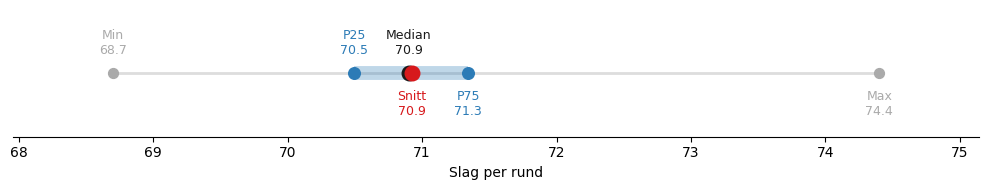

In [135]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["Average Score"], "Slag per rund")
plt.tight_layout()
plt.show()

### Greener i regulation (GIR%)

Toursnitt: **65.7%** — drygt två av tre hål träffas i regulation. Spannet är 20 procentenheter (53.5–73.5%), vilket är den bredaste relativa spridningen av alla mätvärden. En spelare i bottenskiktet missar nästan varannan green — då krävs exceptionell scrambling för att hålla sig på touren.

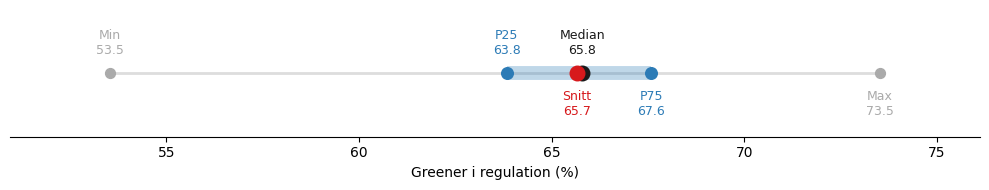

In [136]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["gir"], "Greener i regulation (%)")
plt.tight_layout()
plt.show()

### Fairways träffade (%)

Toursnitt: **61.4%**. Spannet är brett — från 43% till 77%. Låg fairway-procent behöver inte innebära dåligt spel: de längsta slagspelarna offrar medvetet träffsäkerhet för distans. Det ger kortare inlagsspel trots att bollen hamnar i rough.

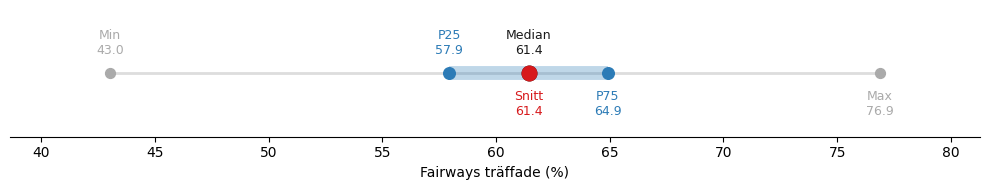

In [137]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["Fairway Percentage"], "Fairways träffade (%)")
plt.tight_layout()
plt.show()

### Drivavstånd (meter)

Toursnitt: **266 meter**. Halva touren slår mellan 261 och 271 meter — ett 10-meters-fönster. Det totala spannet är 49 meter (243–292 m), men de allra kortaste och längsta spelarna är extremfall. Distans ensam avgör inte scoring — vi återkommer till detta.

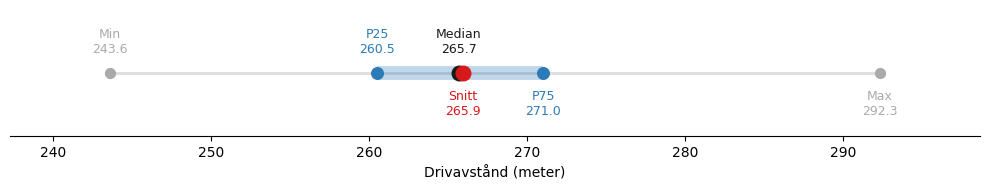

In [138]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["Avg Distance"] * 0.9144, "Drivavstånd (meter)")
plt.tight_layout()
plt.show()

### Puttningar per rund

Toursnitt: **29.2 puttningar per rund**. Det här är den mest extremt täta fördelningen av alla mätvärden — bara 3.5 puttningar skiljer bäste från sämste puttare på touren (27.5–31.0). Halvparten av spelarna puttar 28.8–29.5 gånger. Tre extra puttningar per rund är hela skillnaden mellan elit och botten.

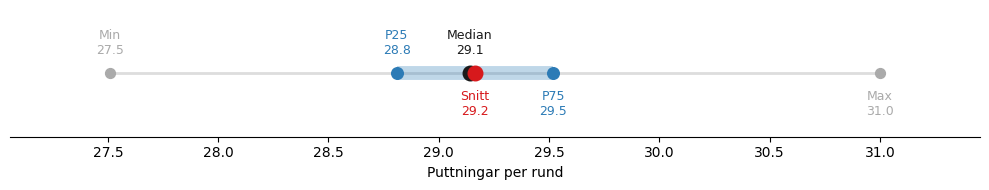

In [139]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["Average Putts"], "Puttningar per rund")
plt.tight_layout()
plt.show()

### Scrambling (%)

Toursnitt: **58.1%** — paret räddas drygt varannan gång spelaren missar greenen. Spannet är brett: 44–69%. Scrambling är en direkt kompensationsmekanism för missade greener — en spelare med låg GIR% är beroende av hög scrambling för att hålla scoringen nere.

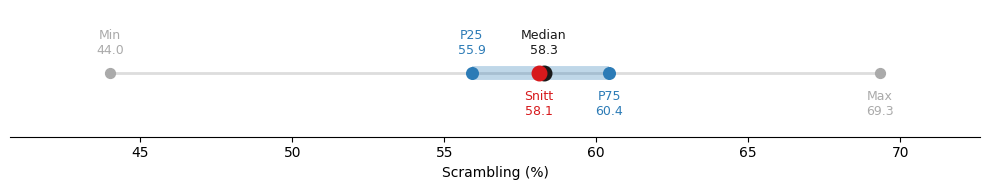

In [140]:
fig, ax = plt.subplots(figsize=(10, 2))
range_plot(ax, df["Average Scrambling"], "Scrambling (%)")
plt.tight_layout()
plt.show()

## Vad hänger ihop med scoring?

Pearson-korrelationen visar hur starkt varje mätvärde hänger ihop med genomsnittlig score per rund. Blå staplar (negativa värden) betyder att mer av detta mätvärde ger lägre — alltså bättre — scoring. Den röda stapeln för putts är avsiktlig: fler puttningar ger direkt sämre score.

In [ ]:
df_corr = df.copy()
df_corr["Putteffektivitet"] = -df_corr["Average Putts"]

metrics = {
    "gir":               "GIR%",
    "Putteffektivitet":  "Putteffektivitet (färre = bättre)",
    "Average Scrambling":"Scrambling%",
    "Fairway Percentage":"Fairway%",
    "Avg Distance":      "Drivavstånd (yard)",
}

corrs = {label: df_corr["Average Score"].corr(df_corr[col]) for col, label in metrics.items()}
corrs = dict(sorted(corrs.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d7191c" if v > 0 else "#2c7bb6" for v in corrs.values()]
ax.barh(list(corrs.keys()), list(corrs.values()), color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for name, val in corrs.items():
    ha = "left" if val > 0 else "right"
    ax.text(val + (0.01 if val > 0 else -0.01),
            list(corrs.keys()).index(name),
            f"{val:.2f}", va="center", ha=ha, fontsize=9)
ax.set_xlabel("Pearson-korrelation med Average Score")
ax.set_title("GIR och puttning korrelerar starkast med scoring")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Nyckelstatistik mot scoring — riktning och styrka

Varje punkt är en spelsäsong. Den röda trendlinjen visar riktningen. En brantare lutning innebär starkare samband. Notera skillnaden mellan GIR och puttning (brant) jämfört med drivavstånd (flack).

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

scatter_metrics = [
    ("gir",                "GIR%",               axes[0, 0], "Fler greener → lägre score"),
    ("Average Putts",      "Puttningar/rund",     axes[0, 1], "Färre putts → lägre score"),
    ("Average Scrambling", "Scrambling%",         axes[1, 0], "Bättre scrambling → lägre score"),
    ("Avg Distance",       "Drivavstånd (yard)",  axes[1, 1], "Distans har svagt samband med score"),
]

for col, xlabel, ax, title in scatter_metrics:
    mask = df[col].notna() & df["Average Score"].notna()
    x = df.loc[mask, col]
    y = df.loc[mask, "Average Score"]
    ax.scatter(x, y, alpha=0.15, s=10, color="#2c7bb6")
    coeffs = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color="#d7191c", linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Slag/rund")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    if col == "Average Putts":
        ax.invert_xaxis()

plt.tight_layout()
plt.show()

## Topp 25% mot botten 25% — konkreta skillnader

Vad skiljer de bästa proffsen från de sämsta? Nedan visas genomsnittsvärdet per mätvärde för de 25% bästa och de 25% sämsta scorarna på touren. Siffrorna visar exakt hur stor skillnaden är — och vilken statistik som hänger ihop med det.

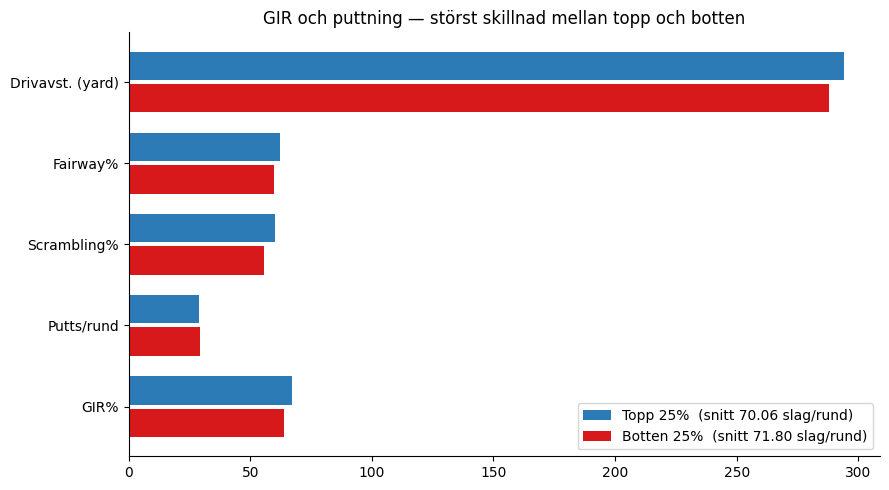

In [143]:
q1_thresh = df["Average Score"].quantile(0.25)
q4_thresh = df["Average Score"].quantile(0.75)
top = df[df["Average Score"] <= q1_thresh].copy()
bot = df[df["Average Score"] >= q4_thresh].copy()

metrics_bar = [
    ("gir",                "GIR%"),
    ("Average Putts",      "Putts/rund"),
    ("Average Scrambling", "Scrambling%"),
    ("Fairway Percentage", "Fairway%"),
    ("Avg Distance",       "Drivavst. (yard)"),
]

top_means = [top[col].mean() for col, _ in metrics_bar]
bot_means = [bot[col].mean() for col, _ in metrics_bar]
ylabels   = [label for _, label in metrics_bar]

x = np.arange(len(ylabels))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(x + 0.2, top_means, height=0.35, color="#2c7bb6",
        label=f"Topp 25%  (snitt {top['Average Score'].mean():.2f} slag/rund)")
ax.barh(x - 0.2, bot_means, height=0.35, color="#d7191c",
        label=f"Botten 25%  (snitt {bot['Average Score'].mean():.2f} slag/rund)")
ax.set_yticks(x)
ax.set_yticklabels(ylabels)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("GIR och puttning — störst skillnad mellan topp och botten")
plt.tight_layout()
plt.show()

## GIR mot scrambling — kompensationsmekanismen

En spelare som missar greener behöver räddas ofta för att hålla nere scoringen. Men räcker det? Diagrammet visar GIR% mot scrambling% där färgen anger scoring — blå är lägst (bäst). Linjerna markerar tour-snittet för vardera mätvärde.

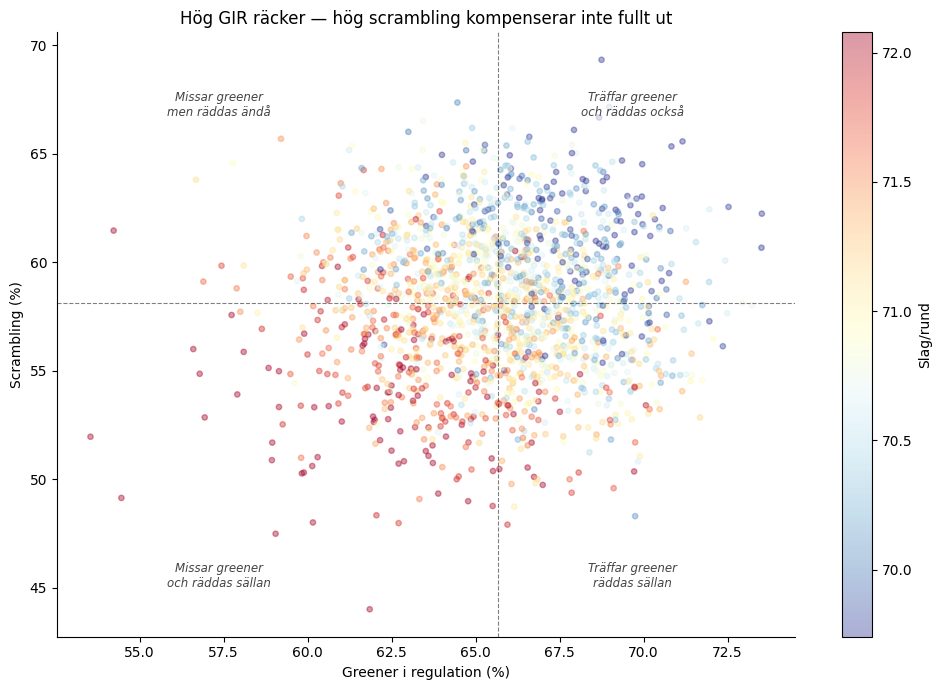

In [144]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df["gir"], df["Average Scrambling"],
    c=df["Average Score"], cmap="RdYlBu_r",
    alpha=0.4, s=15,
    vmin=df["Average Score"].quantile(0.05),
    vmax=df["Average Score"].quantile(0.95),
)
fig.colorbar(sc, ax=ax, label="Slag/rund")

gir_mean = df["gir"].mean()
scr_mean = df["Average Scrambling"].mean()

ax.axvline(gir_mean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(scr_mean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

quadrant_labels = [
    (0.78, 0.88, "Träffar greener\noch räddas också"),
    (0.22, 0.88, "Missar greener\nmen räddas ändå"),
    (0.78, 0.10, "Träffar greener\nräddas sällan"),
    (0.22, 0.10, "Missar greener\noch räddas sällan"),
]
for xr, yr, txt in quadrant_labels:
    ax.text(xr, yr, txt, transform=ax.transAxes, ha="center", va="center",
            fontsize=8.5, color="#444444", style="italic",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2))

ax.set_xlabel("Greener i regulation (%)")
ax.set_ylabel("Scrambling (%)")
ax.set_title("Hög GIR räcker — hög scrambling kompenserar inte fullt ut")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Verifiering med Strokes Gained

Strokes Gained (SG) är ett avancerat mätvärde som mäter hur många slag varje del av spelet bidrar med jämfört med tour-snittet. Det är för komplext för direktjämförelse med amatörer, men fungerar utmärkt som verifiering. Om hypotesen stämmer ska SG:APR (inlagsspelet) och SG Putts ha starkast korrelation med scoring — inte SG:OTT (off the tee, inkl. distans).

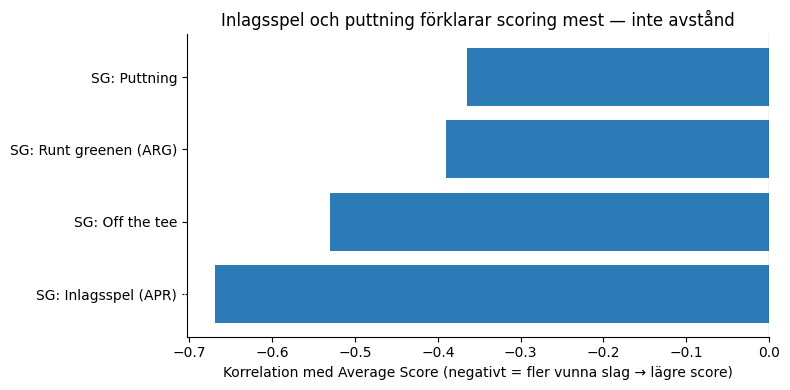

In [145]:
sg_map = {
    "SG:OTT":           "SG: Off the tee",
    "SG:APR":           "SG: Inlagsspel (APR)",
    "SG:ARG":           "SG: Runt greenen (ARG)",
    "Average SG Putts": "SG: Puttning",
}

corrs = {
    label: df["Average Score"].corr(df[col])
    for col, label in sg_map.items()
}
corrs = dict(sorted(corrs.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(corrs.keys()), list(corrs.values()), color="#2c7bb6")
ax.axvline(0, color="black", linewidth=0.8)
for i, (name, val) in enumerate(corrs.items()):
    ax.text(val - 0.01, i, f"{val:.2f}", va="center", ha="right", fontsize=9, color="white")
ax.set_xlabel("Korrelation med Average Score (negativt = fler vunna slag → lägre score)")
ax.set_title("Inlagsspel och puttning förklarar scoring mest — inte avstånd")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()